<div align="center">

  # <span style="color:skyblue;">**Rekomendasi Genre sebagai Landasan Personalisasi: Membangun Pipeline Rekomendasi Film Adaptif dengan Model BERT–Cosine Similarity**</span>
  #### <span style="color:yellow;">Data Analysis Competition IFest 2025</span>



</div>

**Disusun oleh: Heisenberg**

---


<div align="justify">

  # <span style="color:orange;">**Problem Statement**</span>

1. Meskipun data film sangat melimpah, pola-pola yang menentukan kesuksesan sebuah film masih tersembunyi dan memerlukan analisis mendalam untuk mengungkap karakteristik kunci dari film yang populer.

2. Proses analisis seringkali terfragmentasi karena data mentah yang tidak terstruktur dan memiliki nilai kosong menjadi penghalang, sehingga dibutuhkan alur kerja (pipeline) machine learning yang terintegrasi agar prosesnya efisien.

3. Terdapat kesenjangan antara data yang melimpah dengan kebutuhan platform perfilman, yang memerlukan sebuah sistem rekomendasi yang akurat untuk meningkatkan keterlibatan (engagement) dan retensi pengguna.

<div align="justify">

  # <span style="color:orange;">**Goals**</span>
1. Mengidentifikasi karakteristik popularitas film dalam skala besar

2. Merancang pipeline machine learning end-to-end 

3. Dapat dimanfaatkan oleh konsumen dan platform perfilman


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, hamming_loss, precision_score, recall_score, jaccard_score
)
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW

In [ ]:
df = pd.read_csv('/content/dataset_ifest_2025.csv')
df

,movie_title,genre_label,language,summary,popularity,release_date
0,Ace Ventura: When Nature Calls,"Crime,Comedy,Adventure",en,"Summoned from an ashram in Tibet, Ace finds hi...",28.877,1995-11-10
1,The Wave,Thriller,no,"Although theorised, no one is really ready whe...",28.675,2015-08-28
2,Spotlight,NaN,en,The true story of how the Boston Globe uncover...,13.601,2015-11-06
3,The Medallion,"Thriller,Fantasy,Action,Comedy",en,A Hong Kong detective suffers a fatal accident...,17.180,2003-08-15
4,Caro diario,NaN,it,Nanni Moretti recalls in his diary three slice...,6.270,1993-10-12
...,...,...,...,...,...,...
12994,In the Blood,NaN,en,When her husband goes missing during their Car...,17.683,2014-04-04
12995,Little White Lies 2,"Comedy,Drama",fr,"The result of the small handkerchiefs ""Petits ...",12.326,2019-05-01
12996,Twins,Comedy,en,Julius and Vincent Benedict are the results of...,21.198,1988-12-08
12997,Teen Wolf,"Comedy,Fantasy,Romance",en,When a shy teenager's new-found powers help hi...,35.726,1985-08-23


<div align="justify">

  # <span style="color:skyblue;">**Data Understanding**</span>


In [41]:
# Menampilkan jumlah baris dan kolom
print(f"Bentuk data: {df.shape}")

# Menampilkan informasi ringkas (tipe data, nilai non-null)
print("\nInfo Data:")
df.info()

Bentuk data: (12999, 6)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12999 entries, 0 to 12998
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_title   12999 non-null  object 
 1   genre_label   10999 non-null  object 
 2   language      12999 non-null  object 
 3   summary       12994 non-null  object 
 4   popularity    12999 non-null  float64
 5   release_date  12999 non-null  object 
dtypes: float64(1), object(5)
memory usage: 609.5+ KB


In [42]:
#cek duplicated
df.duplicated().sum()

#hapus duplicated
df = df.drop_duplicates()


# Menampilkan jumlah baris dan kolom setelah menghapus duplicated
print(f"Bentuk data: {df.shape}")

# Menampilkan informasi ringkas df setelah menghapus duplicated
print("\nInfo Data:")
df.info()

Bentuk data: (9991, 6)

Info Data:
<class 'pandas.core.frame.DataFrame'>
Index: 9991 entries, 0 to 12994
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_title   9991 non-null   object 
 1   genre_label   7991 non-null   object 
 2   language      9991 non-null   object 
 3   summary       9987 non-null   object 
 4   popularity    9991 non-null   float64
 5   release_date  9991 non-null   object 
dtypes: float64(1), object(5)
memory usage: 546.4+ KB


In [43]:
# Menampilkan statistik deskriptif untuk kolom 'popularity'
df['popularity'].describe()

count     9991.000000
mean        34.723721
std        211.777668
min          0.600000
25%          9.164500
50%         13.646000
75%         25.670000
max      10436.917000
Name: popularity, dtype: float64

In [44]:
# Menghitung 10 bahasa paling umum
df['language'].value_counts().head(10)

language
en    7810
fr     678
it     427
ja     275
es     195
de     104
ko      76
zh      54
cn      54
ru      47
Name: count, dtype: int64

In [45]:
# Memisahkan genre, mengubahnya menjadi satu daftar panjang, lalu menghitungnya
genre_counts = df['genre_label'].dropna().str.split(',').explode().value_counts()
print(genre_counts.head(10))

genre_label
Drama              3606
Comedy             2959
Thriller           2137
Action             1781
Romance            1346
Adventure          1256
Crime              1147
Horror             1114
Family              931
Science Fiction     916
Name: count, dtype: int64


In [47]:
# Ubah kolom menjadi tipe data datetime
df['release_date'] = pd.to_datetime(df['release_date'])

# Lihat tanggal rilis paling awal dan paling akhir
print(f"Film paling awal dirilis: {df['release_date'].min().year}")
print(f"Film paling akhir dirilis: {df['release_date'].max().year}")

Film paling awal dirilis: 1902
Film paling akhir dirilis: 2022


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\916597827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_date'] = pd.to_datetime(df['release_date'])


<div align="justify">

  # <span style="color:orange;">**Analisis Data Eksploratif (EDA)**</span>


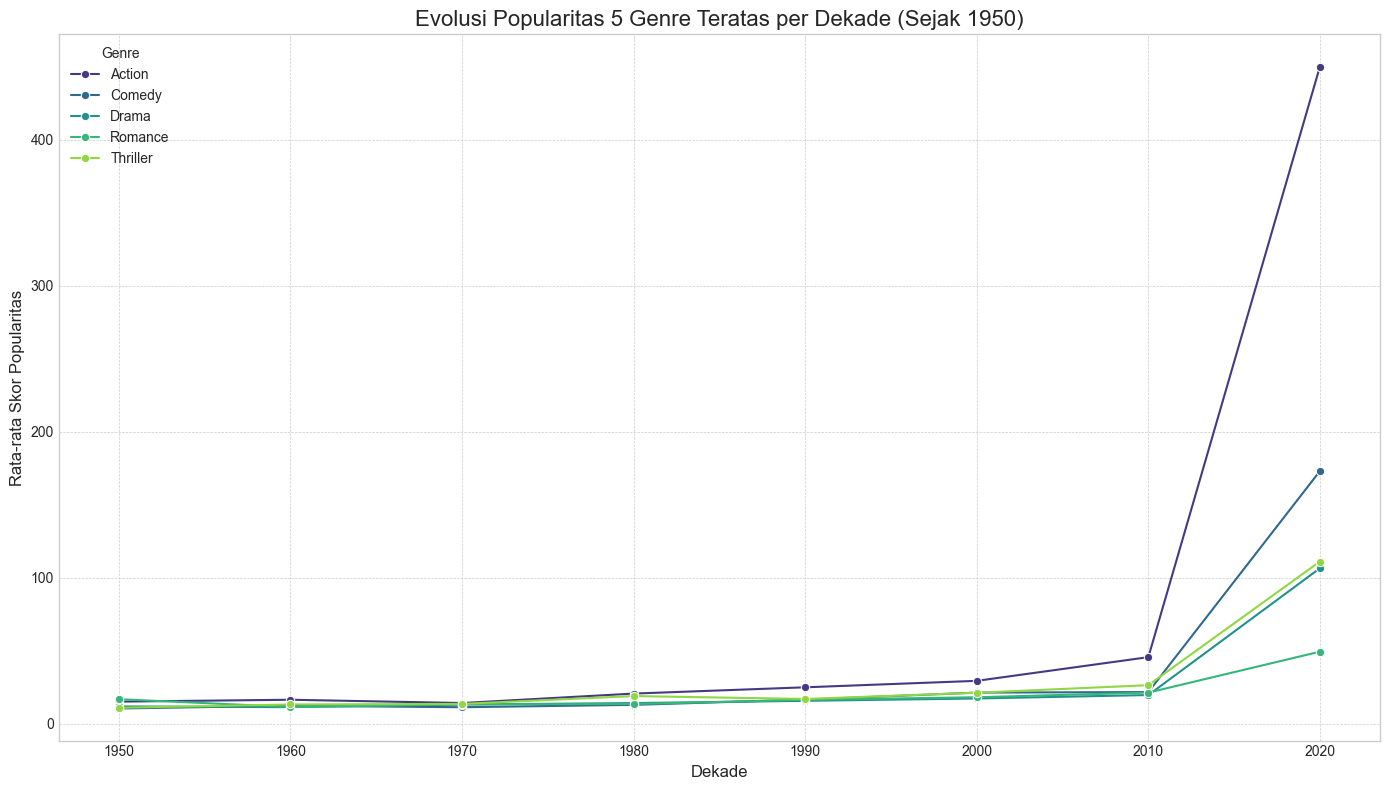

In [ ]:
# --- 1. Persiapan Data dalam Satu Rangkaian (Chaining) ---
# Tentukan 5 genre teratas terlebih dahulu
top_5_genres = df['genre_label'].dropna().str.split(',').explode().value_counts().head(5).index.tolist()

# Lakukan semua transformasi data dalam satu operasi
plot_data = (
    df.assign( 
        release_date=pd.to_datetime(df['release_date']),
        decade=lambda x: (x['release_date'].dt.year // 10) * 10
    )
    .dropna(subset=['genre_label']) # Hapus baris dengan genre kosong
    .assign(genre_label=lambda x: x['genre_label'].str.split(',')) # Ubah string genre menjadi list
    .explode('genre_label') # Buat baris baru untuk setiap genre
    .query("genre_label in @top_5_genres and decade >= 1950") # Filter genre dan dekade dalam satu langkah
    .groupby(['decade', 'genre_label'])['popularity'] # Kelompokkan data
    .mean() # Hitung rata-rata popularitas
    .reset_index() # Kembalikan 'decade' dan 'genre_label' menjadi kolom
)

# --- 2. Visualisasi Data ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=plot_data,
    x='decade',
    y='popularity',
    hue='genre_label',
    marker='o',
    palette='viridis' # Menggunakan palet warna yang berbeda
)

plt.title('Evolusi Popularitas 5 Genre Teratas per Dekade (Sejak 1950)', fontsize=16)
plt.xlabel('Dekade', fontsize=12)
plt.ylabel('Rata-rata Skor Popularitas', fontsize=12)
plt.legend(title='Genre', loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\3351441606.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['genre_count'] = df['genre_label'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)


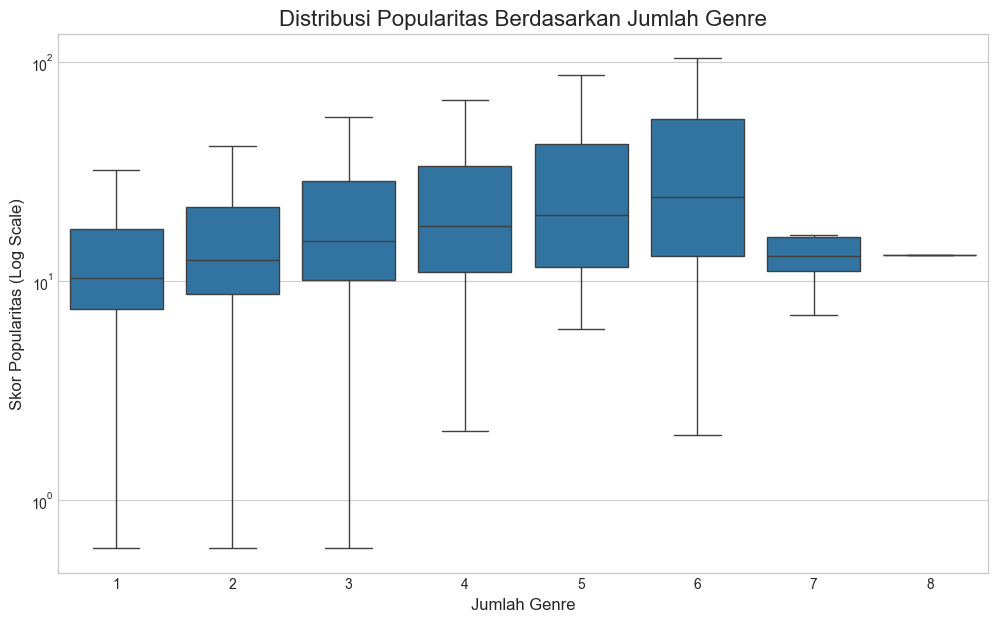

In [49]:
# Hitung jumlah genre untuk setiap film dan simpan di kolom baru
# Kita gunakan .fillna(0) untuk film yang genrenya kosong
df['genre_count'] = df['genre_label'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df[df['genre_count'] > 0], # Filter film yang punya genre
    x='genre_count',
    y='popularity',
    showfliers=False # Kita sembunyikan outlier agar plot lebih jelas
)
plt.title('Distribusi Popularitas Berdasarkan Jumlah Genre', fontsize=16)
plt.xlabel('Jumlah Genre', fontsize=12)
plt.ylabel('Skor Popularitas (Log Scale)', fontsize=12)
plt.yscale('log') # Gunakan skala log karena popularitas sangat skewed
plt.show()

**Insight**
* Tren Positif: Median popularitas film terus naik seiring penambahan genre dari 1 hingga 6. Ini menunjukkan bahwa film yang menggabungkan beberapa elemen cerita (multi-genre) berhasil menarik audiens yang lebih beragam dibandingkan film dengan genre tunggal.

* Puncak Popularitas ("Sweet Spot"): Titik optimal tercapai pada film dengan 6 genre, yang secara konsisten menunjukkan median popularitas tertinggi. Ini adalah "formula" di mana kekayaan cerita mencapai daya tarik komersial maksimal dalam dataset ini.

* Titik Jenuh & Penurunan: Melebihi 6 genre, popularitas menurun drastis. Film dengan 7+ genre memiliki performa yang rendah secara konsisten, menandakan bahwa audiens mungkin menganggap alur ceritanya tidak fokus atau terlalu rumit, sehingga kehilangan daya tarik.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\3558195972.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


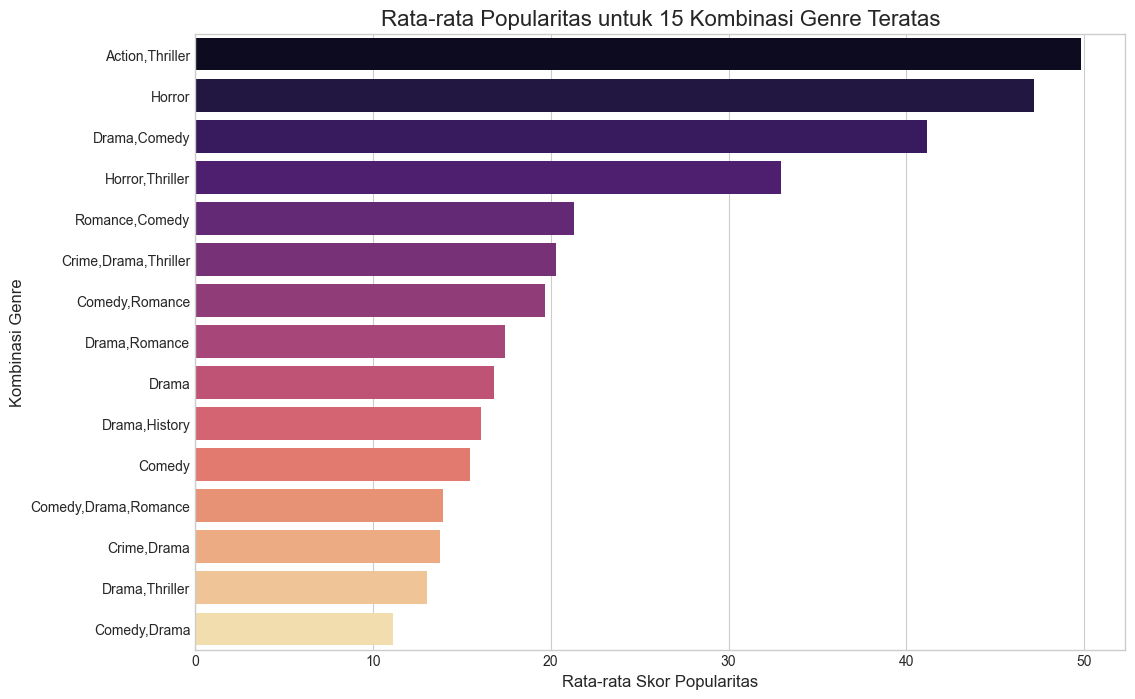

In [50]:
# Hitung 15 kombinasi genre paling umum
top_combinations = df['genre_label'].value_counts().nlargest(15).index.tolist()

# Filter DataFrame agar hanya berisi kombinasi teratas
df_top_combo = df[df['genre_label'].isin(top_combinations)]

# Hitung rata-rata popularitas untuk setiap kombinasi
combo_popularity = df_top_combo.groupby('genre_label')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=combo_popularity.values,
    y=combo_popularity.index,
    palette='magma'
)
plt.title('Rata-rata Popularitas untuk 15 Kombinasi Genre Teratas', fontsize=16)
plt.xlabel('Rata-rata Skor Popularitas', fontsize=12)
plt.ylabel('Kombinasi Genre', fontsize=12)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\1361307664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_date'] = pd.to_datetime(df['release_date'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\1361307664.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_month'] = df['release_date'].dt.month_name()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\1361307664.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

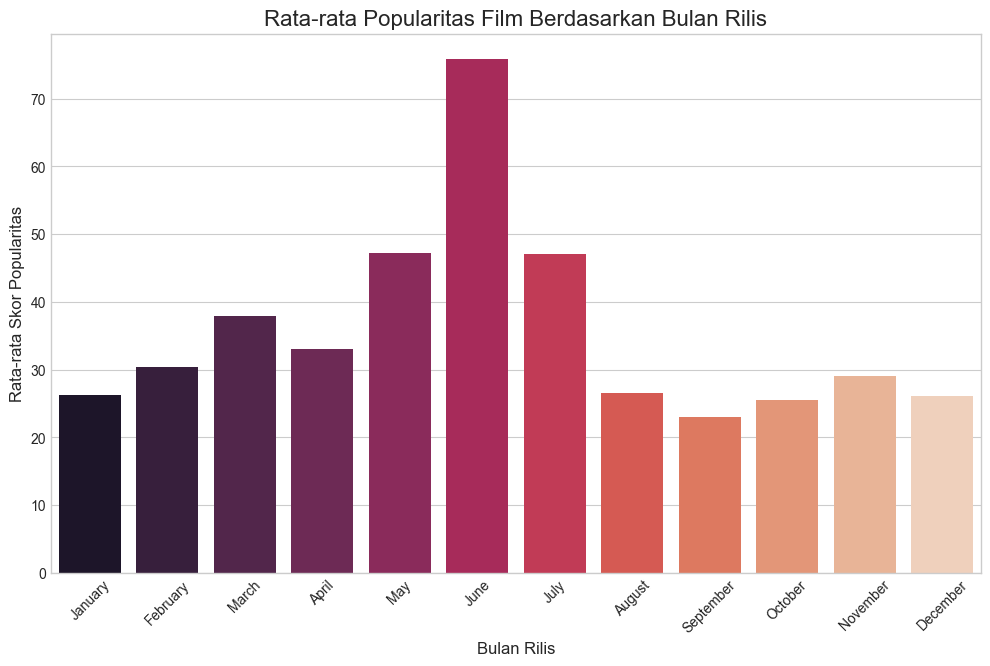

In [ ]:
# Pastikan 'release_date' adalah tipe datetime
df['release_date'] = pd.to_datetime(df['release_date'])

# Buat kolom baru untuk nama bulan
df['release_month'] = df['release_date'].dt.month_name()

# Tentukan urutan bulan yang benar
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Hitung rata-rata popularitas per bulan
monthly_popularity = df.groupby('release_month')['popularity'].mean().reindex(month_order)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=monthly_popularity.index,
    y=monthly_popularity.values,
    palette='rocket'
)

plt.title('Rata-rata Popularitas Film Berdasarkan Bulan Rilis', fontsize=16)
plt.xlabel('Bulan Rilis', fontsize=12)
plt.ylabel('Rata-rata Skor Popularitas', fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Insight**
* Juni: Jendela Eksklusif Blockbuster. Studio film tampaknya memperlakukan bulan Juni sebagai jendela rilis yang premium dan eksklusif. Mereka tidak merilis banyak film, tetapi film yang mereka rilis adalah film-film andalan dengan potensi komersial raksasa. Ini adalah strategi "Kualitas di atas Kuantitas".

* September-Oktober: Pasar Volume Tinggi. Sebaliknya, awal musim gugur digunakan untuk merilis volume film yang sangat besar. Karena rata-rata popularitasnya rendah, ini kemungkinan adalah film-film dengan anggaran lebih kecil, film independen, atau film yang ekspektasinya tidak terlalu tinggi. Ini adalah strategi "Kuantitas di atas Kualitas", mungkin untuk memenuhi kuota rilis atau membersihkan inventaris.

In [ ]:
# Pastikan urutan bulan sudah benar
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Hitung jumlah film yang dirilis setiap bulan
monthly_film_count = df['release_month'].value_counts().reindex(month_order)

# # Tampilkan datanya
# print(monthly_film_count)

# plt.figure(figsize=(12, 7))
# sns.barplot(
#     x=monthly_film_count.index,
#     y=monthly_film_count.values,
#     palette='viridis'
# )

# plt.title('Jumlah Film yang Dirilis per Bulan', fontsize=16)
# plt.xlabel('Bulan Rilis', fontsize=12)
# plt.ylabel('Jumlah Film', fontsize=12)
# plt.xticks(rotation=45)
# plt.show()

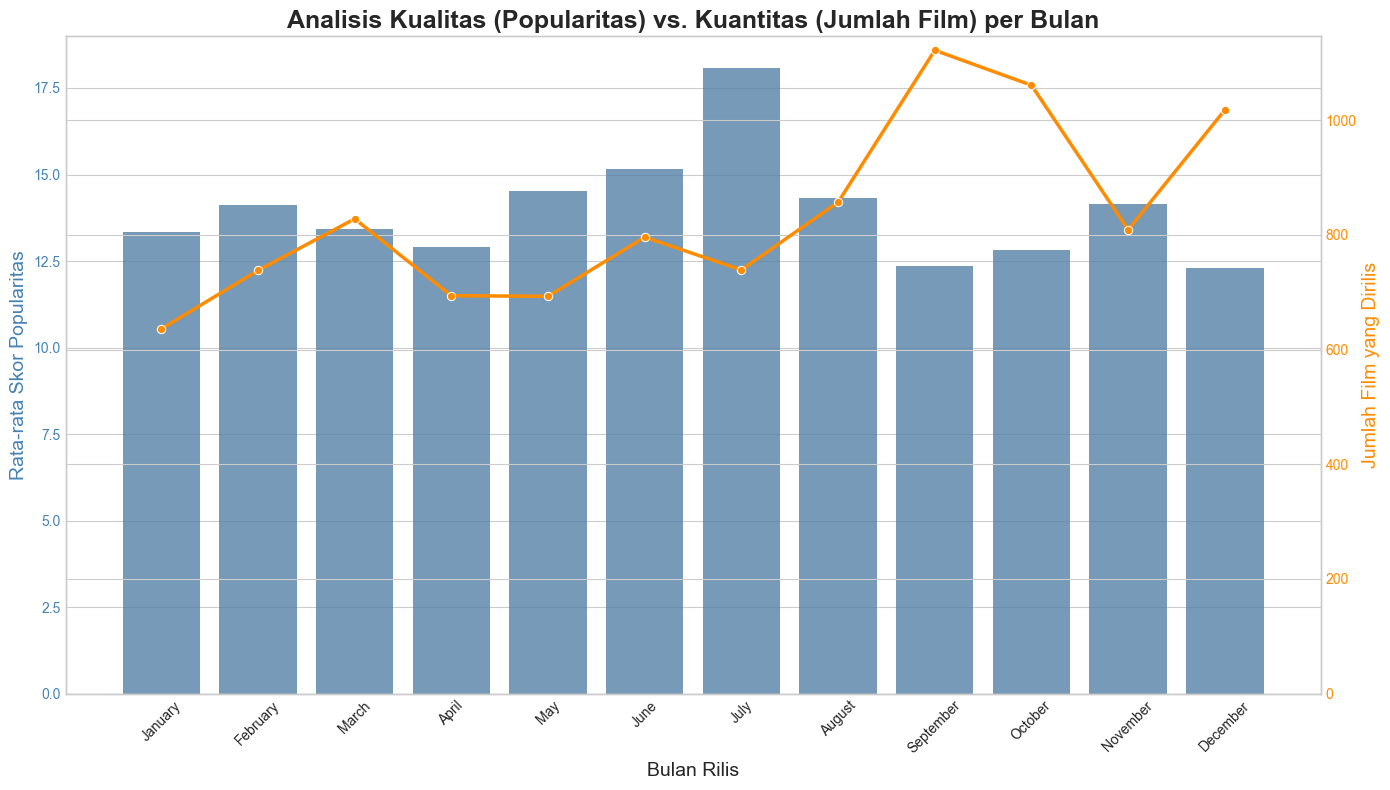

In [ ]:

# 1. PERSIAPAN DATA (Sama seperti sebelumnya)
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_popularity = df.groupby('release_month')['popularity'].median().reindex(month_order)
monthly_film_count = df['release_month'].value_counts().reindex(month_order)

# 2. VISUALISASI DUAL-AXIS YANG DIPERBAIKI
color_popularity = 'steelblue'
color_count = 'darkorange'

fig, ax1 = plt.subplots(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Bar Chart untuk Rata-rata Popularitas (Sumbu Kiri)
sns.barplot(x=monthly_popularity.index, y=monthly_popularity.values, ax=ax1, color=color_popularity, alpha=0.8)
ax1.set_ylabel('Rata-rata Skor Popularitas', fontsize=14, color=color_popularity)
ax1.tick_params(axis='y', labelcolor=color_popularity)
ax1.set_xlabel('Bulan Rilis', fontsize=14)
plt.xticks(rotation=45)

# Buat Sumbu Kedua
ax2 = ax1.twinx()

# Plot Line Chart untuk Jumlah Film (Sumbu Kanan)
sns.lineplot(x=monthly_film_count.index, y=monthly_film_count.values, ax=ax2, color=color_count, marker='o', linewidth=2.5)
ax2.set_ylabel('Jumlah Film yang Dirilis', fontsize=14, color=color_count)
ax2.tick_params(axis='y', labelcolor=color_count)

# --- PERBAIKAN UTAMA ADA DI SINI ---
# Menetapkan batas bawah sumbu Y kanan ke 0 agar tidak melebih-lebihkan perubahan
ax2.set_ylim(bottom=0)

# Judul Utama
plt.title('Analisis Kualitas (Popularitas) vs. Kuantitas (Jumlah Film) per Bulan', fontsize=18, weight='bold')
fig.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\3231548066.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lang_category'] = df['language'].apply(lambda x: 'English' if x == 'en' else 'Non-English')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17116\3231548066.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


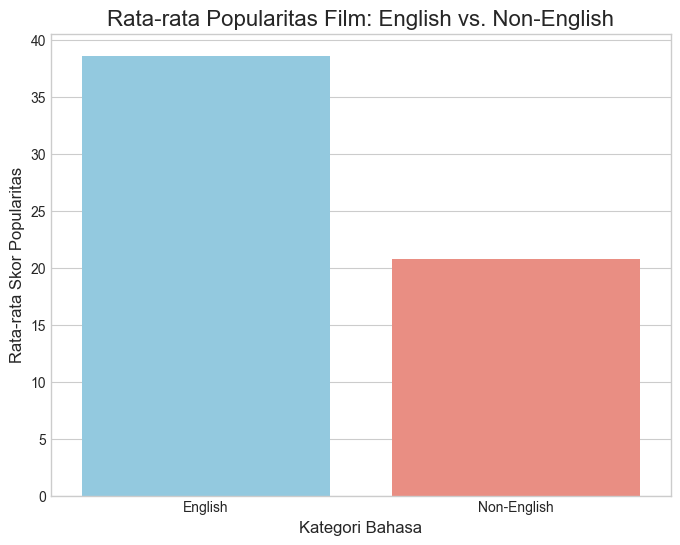

In [ ]:
# Buat kolom baru untuk kategori bahasa
df['lang_category'] = df['language'].apply(lambda x: 'English' if x == 'en' else 'Non-English')


# Hitung rata-rata popularitas untuk setiap kategori
avg_popularity_lang = df.groupby('lang_category')['popularity'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(
    data=avg_popularity_lang,
    x='lang_category',
    y='popularity',
    palette=['skyblue', 'salmon']
)

plt.title('Rata-rata Popularitas Film: English vs. Non-English', fontsize=16)
plt.xlabel('Kategori Bahasa', fontsize=12)
plt.ylabel('Rata-rata Skor Popularitas', fontsize=12)
plt.show()

<div align="justify">

  # <span style="color:orange;">**Modeling For Prediction Missing Genre**</span>


### **1. Model Statistical**

#### a. Model Baselined

In [ ]:
# --- LANGKAH 1 & 2: MEMUAT DAN MEMBERSIHKAN DATA ---
print("--- Memuat dan Membersihkan Data Awal ---")
df = pd.read_csv('dataset_ifest_2025.csv')
print(f"Jumlah baris awal: {len(df)}")

df.drop_duplicates(inplace=True)
print(f"Jumlah baris setelah hapus duplikasi: {len(df)}")

df.dropna(subset=['summary'], inplace=True)
print(f"Jumlah baris setelah hapus summary kosong: {len(df)}")
df.reset_index(drop=True, inplace=True)

# --- LANGKAH 3: MEMISAHKAN DATA ---
df_labeled = df[df['genre_label'].notna()].copy()
df_unlabeled = df[df['genre_label'].isna()].copy()

print(f"\nJumlah data berlabel untuk dilatih/validasi: {len(df_labeled)}")
print(f"Jumlah data tanpa label untuk diprediksi: {len(df_unlabeled)}")

# --- PERSIAPAN UNTUK MODEL ---
mlb = MultiLabelBinarizer()
y_labeled = mlb.fit_transform(df_labeled['genre_label'].str.split(','))
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_labeled = tfidf.fit_transform(df_labeled['summary'])

# --- LANGKAH 4: SPLITTING DATA BERLABEL ---
X_train, X_val, y_train, y_val = train_test_split(
    X_labeled, y_labeled, 
    test_size=0.2, 
    random_state=42
)
print(f"\nUkuran data latih: {X_train.shape[0]}")
print(f"Ukuran data validasi: {X_val.shape[0]}")

# --- MELATIH & MENGEVALUASI MODEL ---
print("\n--- Melatih model Linear SVC ---")
model = OneVsRestClassifier(LinearSVC(random_state=42, dual=True))

start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Selesai dalam {training_time:.2f} detik.")

# Evaluasi model pada set validasi
print("\n--- Mengevaluasi Model pada Data Validasi ---")
y_pred_val = model.predict(X_val)

# Hitung semua metrik yang diminta
jaccard = jaccard_score(y_val, y_pred_val, average='samples') # DITAMBAHKAN KEMBALI
hamming = hamming_loss(y_val, y_pred_val)
micro_f1 = f1_score(y_val, y_pred_val, average='micro')
micro_precision = precision_score(y_val, y_pred_val, average='micro')
micro_recall = recall_score(y_val, y_pred_val, average='micro')
weighted_f1 = f1_score(y_val, y_pred_val, average='weighted')

# Tampilkan hasil dengan format yang Anda inginkan
print(f"Jaccard Score          : {jaccard:.4f}")
print(f"Hamming Loss           : {hamming:.4f}")
print("-------------------------------------------")
print(f"Micro Average F1-Score : {micro_f1:.4f}")
print(f"Micro Average Precision: {micro_precision:.4f}")
print(f"Micro Average Recall   : {micro_recall:.4f}")
print("-------------------------------------------")
print(f"Weighted F1-Score      : {weighted_f1:.4f}")
print("-------------------------------------------")

--- Memuat dan Membersihkan Data Awal ---
Jumlah baris awal: 12999
Jumlah baris setelah hapus duplikasi: 9991
Jumlah baris setelah hapus summary kosong: 9987

Jumlah data berlabel untuk dilatih/validasi: 7988
Jumlah data tanpa label untuk diprediksi: 1999

Ukuran data latih: 6390
Ukuran data validasi: 1598

--- Melatih model Linear SVC ---
Selesai dalam 0.26 detik.

--- Mengevaluasi Model pada Data Validasi ---
Jaccard Score          : 0.3809
Hamming Loss           : 0.1182
-------------------------------------------
Micro Average F1-Score : 0.5141
Micro Average Precision: 0.6386
Micro Average Recall   : 0.4303
-------------------------------------------
Weighted F1-Score      : 0.5019
-------------------------------------------


#### b. Baselined dengan Fiture Enginering

In [ ]:
# --- LANGKAH 1: MEMUAT DATA YANG SUDAH BERSIH ---
# Kita mulai dari data yang sudah bersih dari duplikasi dan summary kosong
df = pd.read_csv('dataset_ifest_2025.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['summary'], inplace=True)
df.reset_index(drop=True, inplace=True)

# --- LANGKAH 2: FEATURE ENGINEERING & PEMISAHAN DATA ---
# Feature Engineering
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# Pisahkan data berlabel untuk dilatih/validasi
df_labeled = df[df['genre_label'].notna()].copy()

# Siapkan data X (fitur) dan y (target)
features = ['summary', 'popularity', 'release_year', 'language']
X_data = df_labeled[features]

mlb = MultiLabelBinarizer()
y_labeled = mlb.fit_transform(df_labeled['genre_label'].str.split(','))

# --- LANGKAH 3: SPLITTING DATA BERLABEL ---
X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_labeled, 
    test_size=0.2, 
    random_state=42
)
print(f"Ukuran data latih: {len(X_train)}")
print(f"Ukuran data validasi: {len(X_val)}")

# --- LANGKAH 4: MEMBUAT PIPELINE PREPROCESSING & MODEL ---
# Definisikan preprocessor dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'summary'),
        ('numeric', StandardScaler(), ['popularity', 'release_year']),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), ['language'])
    ],
    remainder='drop'
)

# Buat pipeline lengkap yang menggabungkan preprocessor dan model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(LinearSVC(random_state=42, dual=True)))
])

# --- LANGKAH 5: MELATIH & MENGEVALUASI PIPELINE ---
print("\n--- Melatih model SVC dengan Feature Engineering ---")
start_time = time.time()
pipeline.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Selesai dalam {training_time:.2f} detik.")

# Evaluasi model pada set validasi
print("\n--- Mengevaluasi Model pada Data Validasi ---")
y_pred_val = pipeline.predict(X_val)

# Hitung semua metrik
jaccard = jaccard_score(y_val, y_pred_val, average='samples')
hamming = hamming_loss(y_val, y_pred_val)
micro_f1 = f1_score(y_val, y_pred_val, average='micro')
micro_precision = precision_score(y_val, y_pred_val, average='micro')
micro_recall = recall_score(y_val, y_pred_val, average='micro')
weighted_f1 = f1_score(y_val, y_pred_val, average='weighted')

# Tampilkan hasil
print(f"Jaccard Score          : {jaccard:.4f}")
print(f"Hamming Loss           : {hamming:.4f}")
print("-------------------------------------------")
print(f"Micro Average F1-Score : {micro_f1:.4f}")
print(f"Micro Average Precision: {micro_precision:.4f}")
print(f"Micro Average Recall   : {micro_recall:.4f}")
print("-------------------------------------------")
print(f"Weighted F1-Score      : {weighted_f1:.4f}")
print("-------------------------------------------")

Ukuran data latih: 6390
Ukuran data validasi: 1598

--- Melatih model SVC dengan Feature Engineering ---


c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iteration

Selesai dalam 3.52 detik.

--- Mengevaluasi Model pada Data Validasi ---
Jaccard Score          : 0.3929
Hamming Loss           : 0.1177
-------------------------------------------
Micro Average F1-Score : 0.5223
Micro Average Precision: 0.6367
Micro Average Recall   : 0.4427
-------------------------------------------
Weighted F1-Score      : 0.5117
-------------------------------------------


#### c. Baseline SVC dengan Hyperparameter Tuning

In [ ]:
# --- LANGKAH 1 & 2: MEMUAT DAN MEMBERSIHKAN DATA ---
print("--- Memuat dan Membersihkan Data Awal ---")
df = pd.read_csv('dataset_ifest_2025.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['summary'], inplace=True)
df.reset_index(drop=True, inplace=True)

# --- LANGKAH 3: MEMISAHKAN DATA ---
df_labeled = df[df['genre_label'].notna()].copy()

# --- PERSIAPAN UNTUK MODEL ---
mlb = MultiLabelBinarizer()
y_labeled = mlb.fit_transform(df_labeled['genre_label'].str.split(','))
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_labeled = tfidf.fit_transform(df_labeled['summary'])

# --- LANGKAH 4: SPLITTING DATA BERLABEL ---
X_train, X_val, y_train, y_val = train_test_split(
    X_labeled, y_labeled, 
    test_size=0.2, 
    random_state=42
)

# --- LANGKAH 5: HYPERPARAMETER TUNING ---
print("\n--- Memulai Hyperparameter Tuning ---")

# Definisikan model dasar
base_model = OneVsRestClassifier(LinearSVC(random_state=42, dual=True))

# Definisikan rentang hyperparameter yang akan diuji
# 'estimator__C' adalah sintaks khusus untuk mengakses parameter C dari LinearSVC di dalam OneVsRestClassifier
param_grid = {
    'estimator__C': [0.1, 1, 10, 100]
}

# Buat objek RandomizedSearchCV
# n_iter=4 berarti akan mencoba 4 kombinasi (dalam kasus ini semua kemungkinan)
# cv=3 berarti menggunakan 3-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=4, 
    cv=3,
    scoring='f1_micro', # Metrik yang dioptimalkan
    verbose=2, # Menampilkan log proses
    random_state=42,
    n_jobs=-1 # Gunakan semua core CPU
)

# Jalankan pencarian
start_time = time.time()
random_search.fit(X_train, y_train)
end_time = time.time()
tuning_time = end_time - start_time
print(f"\nTuning selesai dalam {tuning_time:.2f} detik.")

# Dapatkan model terbaik dan parameternya
best_model = random_search.best_estimator_
print("\nParameter terbaik yang ditemukan:")
print(random_search.best_params_)

# --- LANGKAH 6: EVALUASI MODEL TERBAIK ---
print("\n--- Mengevaluasi Model Terbaik pada Data Validasi ---")
y_pred_val = best_model.predict(X_val)

# Hitung metrik
f1 = f1_score(y_val, y_pred_val, average='micro')
hamming = hamming_loss(y_val, y_pred_val)
jaccard = jaccard_score(y_val, y_pred_val, average='samples')

print(f"Jaccard Score          : {jaccard:.4f}")
print(f"Hamming Loss           : {hamming:.4f}")
print(f"Micro Average F1-Score : {f1:.4f}")

--- Memuat dan Membersihkan Data Awal ---

--- Memulai Hyperparameter Tuning ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Tuning selesai dalam 4.18 detik.

Parameter terbaik yang ditemukan:
{'estimator__C': 1}

--- Mengevaluasi Model Terbaik pada Data Validasi ---
Jaccard Score          : 0.3809
Hamming Loss           : 0.1182
Micro Average F1-Score : 0.5141


####  d. SVC + Feature Engineering + Hyperparameter Tuning

In [ ]:
# --- LANGKAH 1: MEMUAT DATA BERSIH ---
df = pd.read_csv('dataset_ifest_2025.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['summary'], inplace=True)
df.reset_index(drop=True, inplace=True)

# --- LANGKAH 2: FEATURE ENGINEERING & PEMISAHAN DATA ---
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df_labeled = df[df['genre_label'].notna()].copy()

features = ['summary', 'popularity', 'release_year', 'language']
X_data = df_labeled[features]
mlb = MultiLabelBinarizer()
y_labeled = mlb.fit_transform(df_labeled['genre_label'].str.split(','))

# --- LANGKAH 3: SPLITTING DATA ---
X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_labeled, 
    test_size=0.2, 
    random_state=42
)

# --- LANGKAH 4: MEMBUAT PIPELINE PREPROCESSING ---
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'summary'),
        ('numeric', StandardScaler(), ['popularity', 'release_year']),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), ['language'])
    ])

# --- LANGKAH 5: HYPERPARAMETER TUNING DENGAN PIPELINE ---
print("\n--- Memulai Hyperparameter Tuning untuk Model dengan Fitur Tambahan ---")

# Buat pipeline lengkap, namun modelnya belum di-fit
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(LinearSVC(random_state=42, dual=True)))
])

# Definisikan rentang hyperparameter
# Perhatikan sintaks 'classifier__estimator__C' untuk mengakses parameter C
# dari LinearSVC yang berada di dalam OneVsRestClassifier, yang berada di dalam Pipeline
param_grid = {
    'classifier__estimator__C': [0.1, 1, 10, 100]
}

# Buat objek RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=4,
    cv=3,
    scoring='f1_micro',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Jalankan pencarian
start_time = time.time()
random_search.fit(X_train, y_train)
end_time = time.time()
print(f"\nTuning selesai dalam {time.time() - start_time:.2f} detik.")

# Dapatkan model terbaik
best_pipeline = random_search.best_estimator_
print("\nParameter terbaik yang ditemukan:")
print(random_search.best_params_)

# --- LANGKAH 6: EVALUASI MODEL TERBAIK ---
print("\n--- Mengevaluasi Model Terbaik pada Data Validasi ---")
y_pred_val = best_pipeline.predict(X_val)

# Hitung metrik
f1 = f1_score(y_val, y_pred_val, average='micro')
hamming = hamming_loss(y_val, y_pred_val)
jaccard = jaccard_score(y_val, y_pred_val, average='samples')

print(f"Jaccard Score          : {jaccard:.4f}")
print(f"Hamming Loss           : {hamming:.4f}")
print(f"Micro Average F1-Score : {f1:.4f}")


--- Memulai Hyperparameter Tuning untuk Model dengan Fitur Tambahan ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA\Envi_3.10.8\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iteration


Tuning selesai dalam 10.18 detik.

Parameter terbaik yang ditemukan:
{'classifier__estimator__C': 1}

--- Mengevaluasi Model Terbaik pada Data Validasi ---
Jaccard Score          : 0.3929
Hamming Loss           : 0.1177
Micro Average F1-Score : 0.5223


### **2. Model Transformer**

#### a. BERT Tanpa Feature Enginering

In [ ]:
# --- 1. KONFIGURASI ---
MODEL_NAME = 'bert-base-uncased'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

# Hyperparameters
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-5

# --- LANGKAH 1 & 2: MEMUAT DAN MEMBERSIHKAN DATA ---
print("\n--- Memuat dan Membersihkan Data Awal ---")
df = pd.read_csv('dataset_ifest_2025.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['summary'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Total baris setelah dibersihkan: {len(df)}")

# --- LANGKAH 3: MEMISAHKAN DATA ---
df_labeled = df[df['genre_label'].notna()].copy()
df_unlabeled = df[df['genre_label'].isna()].copy()

print(f"\nJumlah data berlabel untuk dilatih/validasi: {len(df_labeled)}")
print(f"Jumlah data tanpa label untuk diprediksi: {len(df_unlabeled)}")

# --- PERSIAPAN UNTUK MODEL ---
mlb = MultiLabelBinarizer()
y_labeled = mlb.fit_transform(df_labeled['genre_label'].str.split(','))
num_labels = len(mlb.classes_)

# --- LANGKAH 4: SPLITTING DATA BERLABEL ---
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_labeled['summary'], y_labeled,
    test_size=0.2,
    random_state=42
)
print(f"\nUkuran data latih: {len(X_train_text)}")
print(f"Ukuran data validasi: {len(X_val_text)}")

# --- (Definisi class dan fungsi) ---
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts.iloc[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len, return_token_type_ids=False,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(label)
        }

class TransformerModel(nn.Module):
    def __init__(self, model_name, num_labels):
        super(TransformerModel, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.linear = nn.Linear(self.bert.config.hidden_size, num_labels)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        dropout_output = self.dropout(pooled_output)
        return self.linear(dropout_output)

def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    for d in data_loader:
        input_ids, attention_mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    return total_loss / len(data_loader)

def eval_model(model, data_loader, device):
    model.eval()
    fin_targets, fin_outputs = [], []
    with torch.no_grad():
        for d in data_loader:
            input_ids, attention_mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
            outputs = model(input_ids, attention_mask)
            fin_targets.extend(labels.cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())
    return np.array(fin_outputs), np.array(fin_targets)

# --- MEMULAI TRAINING ---
print("\n--- Memulai Training Baseline Model BERT ---")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = TextDataset(X_train_text, y_train, tokenizer, MAX_LEN)
val_dataset = TextDataset(X_val_text, y_val, tokenizer, MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = TransformerModel(MODEL_NAME, num_labels).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
    print(f'  Train loss: {train_loss:.4f}')

    val_outputs, val_targets = eval_model(model, val_loader, device)
    val_binary_outputs = (val_outputs > 0.5).astype(int)
    val_f1_micro = f1_score(val_targets, val_binary_outputs, average='micro')
    print(f'  Validation F1 Score: {val_f1_micro:.4f}')
    print('-' * 20)

Menggunakan device: cuda

--- Memuat dan Membersihkan Data Awal ---
Total baris setelah dibersihkan: 9987

Jumlah data berlabel untuk dilatih/validasi: 7988
Jumlah data tanpa label untuk diprediksi: 1999

Ukuran data latih: 6390
Ukuran data validasi: 1598

--- Memulai Training Baseline Model BERT ---
Epoch 1/5
  Train loss: 0.2826
  Validation F1 Score: 0.5822
--------------------
Epoch 2/5
  Train loss: 0.2083
  Validation F1 Score: 0.6404
--------------------
Epoch 3/5
  Train loss: 0.1647
  Validation F1 Score: 0.6612
--------------------
Epoch 4/5
  Train loss: 0.1287
  Validation F1 Score: 0.6451
--------------------
Epoch 5/5
  Train loss: 0.0992
  Validation F1 Score: 0.6524
--------------------


#### b. BERT + Feature Enginering

In [ ]:
# --- 1. KONFIGURASI ---
MODEL_NAME = 'bert-base-uncased'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

# Hyperparameters
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-5

# --- 2. MEMUAT, MEMBERSIHKAN, & FEATURE ENGINEERING ---
print("\n--- Memuat & Mempersiapkan Data ---")
df = pd.read_csv('dataset_ifest_2025.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['summary'], inplace=True)
df.reset_index(drop=True, inplace=True)

df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# --- 3. PEMISAHAN DATA & PREPROCESSING ---
df_labeled = df[df['genre_label'].notna()].copy()

X_data = df_labeled[['summary', 'popularity', 'release_year', 'language']]
mlb = MultiLabelBinarizer()
y_labels = mlb.fit_transform(df_labeled['genre_label'].str.split(','))
num_labels = len(mlb.classes_)

X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_labels, test_size=0.2, random_state=42
)

numeric_features = ['popularity', 'release_year']
categorical_features = ['language']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
num_non_text_features = X_train_processed.shape[1]

# --- 4. PYTORCH DATASET & MODEL ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class CombinedFeatureDataset(Dataset):
    def __init__(self, texts, non_text_features, labels, tokenizer, max_len):
        self.texts, self.non_text_features, self.labels, self.tokenizer, self.max_len = texts, torch.FloatTensor(non_text_features.toarray()), labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts.iloc[item])
        encoding = self.tokenizer.encode_plus(text, add_special_tokens=True, max_length=self.max_len, return_token_type_ids=False, padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(), 'non_text_features': self.non_text_features[item], 'labels': torch.FloatTensor(self.labels[item])}

train_dataset = CombinedFeatureDataset(X_train['summary'], X_train_processed, y_train, tokenizer, MAX_LEN)
val_dataset = CombinedFeatureDataset(X_val['summary'], X_val_processed, y_val, tokenizer, MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

class CombinedModel(nn.Module):
    def __init__(self, model_name, num_labels, num_non_text_features):
        super(CombinedModel, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(self.bert.config.hidden_size + num_non_text_features, num_labels))
    def forward(self, input_ids, attention_mask, non_text_features):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_embedding = bert_output.last_hidden_state[:, 0, :]
        combined_features = torch.cat([text_embedding, non_text_features], dim=1)
        return self.classifier(combined_features)

model = CombinedModel(MODEL_NAME, num_labels, num_non_text_features).to(device)

# --- (Fungsi train & eval tetap sama) ---
def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train(); total_loss = 0
    for d in data_loader:
        outputs = model(d["input_ids"].to(device), d["attention_mask"].to(device), d["non_text_features"].to(device))
        loss = loss_fn(outputs, d["labels"].to(device)); total_loss += loss.item()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    return total_loss / len(data_loader)

def eval_model(model, data_loader, device):
    model.eval(); fin_targets, fin_outputs = [], []
    with torch.no_grad():
        for d in data_loader:
            outputs = model(d["input_ids"].to(device), d["attention_mask"].to(device), d["non_text_features"].to(device))
            fin_targets.extend(d["labels"].cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())
    return np.array(fin_outputs), np.array(fin_targets)

# --- 5. MENJALANKAN TRAINING ---
print("\n--- Memulai Training BERT + Feature Engineering ---")
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.BCEWithLogitsLoss()
best_f1_score = 0
best_epoch = 0

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
    print(f'  Train loss: {train_loss:.4f}')

    # --- PERUBAHAN UTAMA: Menghitung & Menampilkan Semua Metrik ---
    val_outputs, val_targets = eval_model(model, val_loader, device)
    val_binary_outputs = (val_outputs > 0.5).astype(int)

    val_f1_micro = f1_score(val_targets, val_binary_outputs, average='micro')
    val_jaccard = jaccard_score(val_targets, val_binary_outputs, average='samples')
    val_hamming = hamming_loss(val_targets, val_binary_outputs)

    print(f'  Validation F1 Score (Micro): {val_f1_micro:.4f}')
    print(f'  Validation Jaccard Score   : {val_jaccard:.4f}')
    print(f'  Validation Hamming Loss    : {val_hamming:.4f}')

    if val_f1_micro > best_f1_score:
        best_f1_score = val_f1_micro
        best_epoch = epoch + 1

    print('-' * 20)

print("\n--- Training Selesai ---")
print(f"F1 Score tertinggi dicapai pada Epoch ke-{best_epoch} dengan skor: {best_f1_score:.4f}")

Menggunakan device: cuda

--- Memuat & Mempersiapkan Data ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


--- Memulai Training BERT + Feature Engineering ---
Epoch 1/5
  Train loss: 0.2832
  Validation F1 Score (Micro): 0.5775
  Validation Jaccard Score   : 0.4550
  Validation Hamming Loss    : 0.0997
--------------------
Epoch 2/5
  Train loss: 0.2089
  Validation F1 Score (Micro): 0.6277
  Validation Jaccard Score   : 0.5126
  Validation Hamming Loss    : 0.0909
--------------------
Epoch 3/5
  Train loss: 0.1650
  Validation F1 Score (Micro): 0.6636
  Validation Jaccard Score   : 0.5469
  Validation Hamming Loss    : 0.0907
--------------------
Epoch 4/5
  Train loss: 0.1289
  Validation F1 Score (Micro): 0.6548
  Validation Jaccard Score   : 0.5378
  Validation Hamming Loss    : 0.0921
--------------------
Epoch 5/5
  Train loss: 0.1004
  Validation F1 Score (Micro): 0.6629
  Validation Jaccard Score   : 0.5440
  Validation Hamming Loss    : 0.0931
--------------------

--- Training Selesai ---
F1 Score tertinggi dicapai pada Epoch ke-3 dengan skor: 0.6636


<div align="justify">

  # <span style="color:orange;">**Prediction dengan Model Terbaik**</span>


In [ ]:
# --- LANGKAH 1: PERSIAPAN DATA TANPA LABEL ---
print("--- Mempersiapkan data tanpa label untuk diprediksi ---")

# Pisahkan data tanpa label dari DataFrame df yang sudah bersih
df_unlabeled = df[df['genre_label'].isna()].copy()
print(f"Ditemukan {len(df_unlabeled)} film untuk diprediksi.")

# Terapkan feature engineering yang sama
df_unlabeled['release_date'] = pd.to_datetime(df_unlabeled['release_date'])
df_unlabeled['release_year'] = df_unlabeled['release_date'].dt.year

# Gunakan preprocessor yang SUDAH di-fit untuk mentransformasi data
X_unlabeled_processed = preprocessor.transform(df_unlabeled[['popularity', 'release_year', 'language']])

# Buat Dataset dan DataLoader untuk prediksi
predict_dataset = CombinedFeatureDataset(
    texts=df_unlabeled['summary'],
    non_text_features=X_unlabeled_processed,
    labels=None,  # Tidak ada label untuk data ini
    tokenizer=tokenizer,
    max_len=MAX_LEN
)
# Perbaikan kecil pada class __init__ dan __getitem__ untuk handle labels=None
# (Catatan: Kode di bawah ini sudah disesuaikan agar berjalan tanpa error saat labels=None)
class CombinedFeatureDataset(Dataset):
    def __init__(self, texts, non_text_features, labels, tokenizer, max_len):
        self.texts = texts
        self.non_text_features = torch.FloatTensor(non_text_features.toarray() if hasattr(non_text_features, "toarray") else non_text_features)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts.iloc[item])
        encoding = self.tokenizer.encode_plus(text, add_special_tokens=True, max_length=self.max_len, return_token_type_ids=False, padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt')
        item_data = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'non_text_features': self.non_text_features[item]
        }
        if self.labels is not None:
            item_data['labels'] = torch.FloatTensor(self.labels[item])
        return item_data

predict_dataset = CombinedFeatureDataset(df_unlabeled['summary'], X_unlabeled_processed, None, tokenizer, MAX_LEN)
predict_loader = DataLoader(predict_dataset, batch_size=BATCH_SIZE * 2) # Batch size bisa diperbesar saat prediksi

# --- LANGKAH 2: JALANKAN PREDIKSI ---
print("\n--- Memulai prediksi genre ---")
model.eval()  # Set model ke mode evaluasi
all_predictions = []

with torch.no_grad():
    for d in predict_loader:
        outputs = model(
            input_ids=d["input_ids"].to(device),
            attention_mask=d["attention_mask"].to(device),
            non_text_features=d["non_text_features"].to(device)
        )
        binary_preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(int)
        all_predictions.extend(binary_preds)

print("Prediksi selesai.")

# --- LANGKAH 3: ISI DATA KOSONG DAN SIMPAN ---
# Ubah prediksi biner kembali ke label teks
predicted_genres_text = mlb.inverse_transform(np.array(all_predictions))
# Format menjadi string "Genre1,Genre2,..." (beri 'Unknown' jika tidak ada prediksi)
formatted_genres = [','.join(genres) if genres else 'Unknown' for genres in predicted_genres_text]

# Isi nilai kosong di DataFrame asli
df.loc[df_unlabeled.index, 'genre_label'] = formatted_genres

# Hapus baris yang mungkin masih kosong atau hasilnya 'Unknown' jika tidak diinginkan
df.dropna(subset=['genre_label'], inplace=True)
df = df[df['genre_label'] != 'Unknown']

# Simpan ke file CSV baru
nama_file_final = 'dataset_final_lengkap.csv'
df.to_csv(nama_file_final, index=False)

print(f"\nDataset lengkap dan bersih telah disimpan sebagai '{nama_file_final}'")
print("Jumlah nilai kosong di 'genre_label' sekarang:", df['genre_label'].isna().sum())
print("\nSelesai! 🚀")

--- Mempersiapkan data tanpa label untuk diprediksi ---
Ditemukan 1999 film untuk diprediksi.

--- Memulai prediksi genre ---
Prediksi selesai.

Dataset lengkap dan bersih telah disimpan sebagai 'dataset_final_lengkap.csv'
Jumlah nilai kosong di 'genre_label' sekarang: 0

Selesai! 🚀


In [ ]:
# --- Verifikasi Hasil Pengisian Data (Versi Perbaikan) ---

print("--- Verifikasi Hasil Pengisian Data ---")
print(f"Jumlah nilai kosong di 'genre_label' setelah diisi: {df['genre_label'].isna().sum()}")
print("\nContoh hasil pengisian genre:")

# Temukan indeks yang valid (indeks yang ada di df_unlabeled DAN juga masih ada di df)
valid_indices = df_unlabeled.index.intersection(df.index)

# Tampilkan 5 contoh pertama dari indeks yang valid tersebut
display(df.loc[valid_indices].head()[['movie_title', 'genre_label']])

--- Verifikasi Hasil Pengisian Data ---
Jumlah nilai kosong di 'genre_label' setelah diisi: 0

Contoh hasil pengisian genre:


,movie_title,genre_label
2,Spotlight,Drama
4,Caro diario,Drama
6,Layer Cake,"Action,Comedy,Crime"
20,Phone Booth,"Action,Comedy,Crime,Thriller"
25,Yes Day,"Comedy,Family"


<div align="justify">

  # <span style="color:orange;">**System Recomendation**</span>


### **1. TF-IDF + Cosine Similarity**

In [ ]:
# --- 1. KONFIGURASI ---
K_VALUES = [5, 10, 15] # Nilai K yang akan kita evaluasi

# --- 2. MEMUAT DATA LENGKAP ---
# Pastikan ini adalah file CSV final yang sudah bersih dan lengkap
df_final = pd.read_csv('dataset_final_lengkap.csv')
print(f"Dataset lengkap dimuat dengan {len(df_final)} film.")

# --- 3. MEMBUAT FITUR KONTEN & MATRIKS TF-IDF ---
# Gabungkan fitur teks untuk membuat "profil konten"
df_final['content_dna'] = df_final['movie_title'] + ' ' + df_final['genre_label'] + ' ' + df_final['summary']

# Buat matriks TF-IDF dari profil konten
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_final['content_dna'])
print(f"Bentuk matriks TF-IDF: {tfidf_matrix.shape}")

# --- 4. BAGI DATA UNTUK EVALUASI ---
# Kita hanya perlu membagi indeksnya saja
indices = df_final.index.tolist()
train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42)

# Pisahkan matriks TF-IDF dan DataFrame berdasarkan indeks
train_matrix = tfidf_matrix[train_indices]
train_df = df_final.iloc[train_indices]

# --- 5. PROSES EVALUASI ---
print(f"\nMemulai proses evaluasi Precision@K untuk K={K_VALUES}...")

# Siapkan dictionary untuk menyimpan hasil presisi
all_precisions = {k: [] for k in K_VALUES}

# Loop untuk setiap film di set pengujian
for test_idx in tqdm(test_indices):
    # Ambil data film "pengguna" dari test set
    user_movie = df_final.iloc[test_idx]
    user_vector = tfidf_matrix[test_idx]
    user_genres = set(user_movie['genre_label'].split(','))

    # Hitung kemiripan dengan semua film di train set
    sim_scores = cosine_similarity(user_vector, train_matrix)[0]

    # Ambil indeks film paling mirip (cukup ambil K terbesar, yaitu 15)
    top_indices_in_train = sim_scores.argsort()[-max(K_VALUES):][::-1]
    recommended_movies = train_df.iloc[top_indices_in_train]

    # Hitung 'hits' untuk setiap nilai K
    for k in K_VALUES:
        # Ambil top-k rekomendasi dari daftar yang sudah diurutkan
        top_k_recs = recommended_movies.head(k)

        hits = 0
        for _, movie in top_k_recs.iterrows():
            recommended_genres = set(movie['genre_label'].split(','))
            # Jika ada irisan genre, hitung sebagai 'hit'
            if user_genres.intersection(recommended_genres):
                hits += 1

        # Hitung Precision@k dan simpan
        precision_at_k = hits / k
        all_precisions[k].append(precision_at_k)

# --- 6. TAMPILKAN HASIL EVALUASI ---
print("\n--- Hasil Evaluasi Sistem Rekomendasi (TF-IDF) ---")
for k in K_VALUES:
    avg_precision = np.mean(all_precisions[k])
    print(f"Rata-rata Precision@{k:<2}: {avg_precision:.2%}")

Dataset lengkap dimuat dengan 9985 film.
Bentuk matriks TF-IDF: (9985, 29571)

Memulai proses evaluasi Precision@K untuk K=[5, 10, 15]...


100%|██████████| 1997/1997 [00:16<00:00, 119.39it/s]


--- Hasil Evaluasi Sistem Rekomendasi (TF-IDF) ---
Rata-rata Precision@5 : 76.31%
Rata-rata Precision@10: 74.99%
Rata-rata Precision@15: 74.36%


### **2. BERT + Cosine Similarity**

In [ ]:
# --- 1. KONFIGURASI ---
MODEL_NAME = 'bert-base-uncased'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

# Hyperparameters & Konfigurasi Evaluasi
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 3 # Menggunakan 3 epoch sesuai hasil terbaik sebelumnya
LEARNING_RATE = 2e-5
K_VALUES = [5, 10, 15] # Nilai K yang akan dievaluasi

# --- 2. MEMUAT & MEMPERSIAPKAN DATA ---
print("\n--- Memuat & Mempersiapkan Data ---")
df_final = pd.read_csv('dataset_final_lengkap.csv')
df_final['release_date'] = pd.to_datetime(df_final['release_date'])
df_final['release_year'] = df_final['release_date'].dt.year

# --- (Definisi class dan fungsi) ---
class CombinedFeatureDataset(Dataset):
    def __init__(self, texts, non_text_features, labels, tokenizer, max_len):
        self.texts, self.non_text_features, self.labels, self.tokenizer, self.max_len = texts, torch.FloatTensor(non_text_features.toarray()), labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts.iloc[item])
        encoding = self.tokenizer.encode_plus(text, add_special_tokens=True, max_length=self.max_len, return_token_type_ids=False, padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(), 'non_text_features': self.non_text_features[item], 'labels': torch.FloatTensor(self.labels[item])}

class CombinedModel(nn.Module):
    def __init__(self, model_name, num_labels, num_non_text_features):
        super(CombinedModel, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(self.bert.config.hidden_size + num_non_text_features, num_labels))
    def forward(self, input_ids, attention_mask, non_text_features):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_embedding = bert_output.last_hidden_state[:, 0, :]
        combined_features = torch.cat([text_embedding, non_text_features], dim=1)
        return self.classifier(combined_features)

def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train(); total_loss = 0
    for d in data_loader:
        outputs = model(d["input_ids"].to(device), d["attention_mask"].to(device), d["non_text_features"].to(device))
        loss = loss_fn(outputs, d["labels"].to(device)); total_loss += loss.item()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    return total_loss / len(data_loader)

def get_bert_embedding(text, model, tokenizer):
    encoded_input = tokenizer(text, padding=True, truncation=True, return_tensors='pt', max_length=MAX_LEN)
    encoded_input = {key: val.to(device) for key, val in encoded_input.items()}
    with torch.no_grad():
        model_output = model(**encoded_input)
    return model_output.last_hidden_state[:, 0, :].cpu().numpy()

# --- 3. PERSIAPAN DATA & PREPROCESSING UNTUK TRAINING ---
X_data = df_final[['summary', 'popularity', 'release_year', 'language']]
mlb = MultiLabelBinarizer()
y_labels = mlb.fit_transform(df_final['genre_label'].str.split(','))
num_labels = len(mlb.classes_)

numeric_features = ['popularity', 'release_year']
categorical_features = ['language']
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
X_processed = preprocessor.fit_transform(X_data)
num_non_text_features = X_processed.shape[1]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset_full = CombinedFeatureDataset(X_data['summary'], X_processed, y_labels, tokenizer, MAX_LEN)
train_loader_full = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, shuffle=True)

# --- 4. MELATIH MODEL FINAL PADA SEMUA DATA ---
print("\n--- Melatih Model Final (BERT + Fitur) ---")
model = CombinedModel(MODEL_NAME, num_labels, num_non_text_features).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader_full, loss_fn, optimizer, device)
    print(f'Epoch {epoch + 1}/{EPOCHS}, Train loss: {train_loss:.4f}')

# --- 5. MEMBUAT EMBEDDINGS UNTUK SEMUA FILM ---
print("\nMemuat model terbaik dan membuat embeddings...")
bert_model = model.bert
bert_model.eval()

batch_size_inference = 32
all_embeddings = []
for i in tqdm(range(0, len(df_final), batch_size_inference)):
    batch_texts = df_final['summary'].iloc[i:i+batch_size_inference].tolist()
    embeddings = get_bert_embedding(batch_texts, bert_model, tokenizer)
    all_embeddings.append(embeddings)
movie_embeddings = np.vstack(all_embeddings)

# --- 6. EVALUASI SISTEM REKOMENDASI ---
print(f"\nMemulai proses evaluasi Precision@K untuk K={K_VALUES}...")
train_indices, test_indices = train_test_split(df_final.index.tolist(), test_size=0.2, random_state=42)
train_embeddings = movie_embeddings[train_indices]
train_df = df_final.iloc[train_indices]

all_precisions = {k: [] for k in K_VALUES}

for test_idx in tqdm(test_indices):
    user_movie = df_final.iloc[test_idx]
    user_embedding = movie_embeddings[test_idx].reshape(1, -1)
    user_genres = set(user_movie['genre_label'].split(','))

    sim_scores = cosine_similarity(user_embedding, train_embeddings)[0]

    top_indices = sim_scores.argsort()[-max(K_VALUES):][::-1]
    recommended_movies = train_df.iloc[top_indices]

    for k in K_VALUES:
        top_k_recs = recommended_movies.head(k)
        hits = 0
        for _, movie in top_k_recs.iterrows():
            if user_genres.intersection(set(movie['genre_label'].split(','))):
                hits += 1
        all_precisions[k].append(hits / k)

# --- 7. TAMPILKAN HASIL AKHIR ---
print("\n--- Hasil Evaluasi Sistem Rekomendasi (BERT) ---")
for k in K_VALUES:
    avg_precision = np.mean(all_precisions[k])
    print(f"Rata-rata Precision@{k:<2}: {avg_precision:.2%}")

Menggunakan device: cuda

--- Memuat & Mempersiapkan Data ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Epoch 1/3, Train loss: 0.2524
Epoch 2/3, Train loss: 0.1796
Epoch 3/3, Train loss: 0.1379

Memuat model terbaik dan membuat embeddings...


100%|██████████| 313/313 [01:22<00:00,  3.81it/s]



Memulai proses evaluasi Precision@K untuk K=[5, 10, 15]...


100%|██████████| 1997/1997 [00:55<00:00, 35.76it/s]


--- Hasil Evaluasi Sistem Rekomendasi (BERT) ---
Rata-rata Precision@5 : 99.60%
Rata-rata Precision@10: 99.59%
Rata-rata Precision@15: 99.59%


In [ ]:
# --- FUNGSI REKOMENDASI ---

# Buat series untuk memetakan judul film ke indeksnya untuk pencarian cepat
indices_map = pd.Series(df_final.index, index=df_final['movie_title'])

def recommend_similar_movies(title, data, embeddings, top_n=10):
    """
    Memberikan rekomendasi film berdasarkan kemiripan embedding.
    """
    # Cek apakah judul ada di dalam data
    if title not in indices_map:
        return f"Film dengan judul '{title}' tidak ditemukan."

    # Dapatkan indeks dari film yang cocok dengan judul
    idx = indices_map[title]
    # Handle jika ada judul duplikat, ambil yang pertama
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Ambil embedding dari film tersebut dan reshape
    movie_embedding = embeddings[idx].reshape(1, -1)

    # Hitung cosine similarity antara film tersebut dengan semua film lain
    sim_scores = cosine_similarity(movie_embedding, embeddings)[0]

    # Buat daftar (indeks, skor) dan urutkan
    sim_scores_list = sorted(list(enumerate(sim_scores)), key=lambda x: x[1], reverse=True)

    # Ambil skor dari N film paling mirip (abaikan film itu sendiri)
    top_scores = sim_scores_list[1 : top_n + 1]

    # Dapatkan indeks filmnya
    movie_indices = [i[0] for i in top_scores]

    # Kembalikan judul film paling mirip
    return data['movie_title'].iloc[movie_indices]

# --- PANGGIL FUNGSI UNTUK MENDAPATKAN REKOMENDASI ---
target_movie_title = 'Captain America: The First Avenger'
recommendations = recommend_similar_movies(
    title=target_movie_title,
    data=df_final,
    embeddings=movie_embeddings
)

# --- TAMPILKAN HASIL ---
print(f"--- 10 Rekomendasi Film Teratas Setelah Menonton '{target_movie_title}' ---")
if isinstance(recommendations, str):
    print(recommendations)
else:
    # Menggunakan to_string() untuk tampilan yang lebih rapi
    print(recommendations.reset_index(drop=True).to_string(index=True))

--- 10 Rekomendasi Film Teratas Setelah Menonton 'Captain America: The First Avenger' ---
0    Transformers: Revenge of the Fallen
1          Transformers: The Last Knight
2                    The Incredible Hulk
3           Ultimate Avengers: The Movie
4        Transformers: Age of Extinction
5                Star Trek: Insurrection
6                            Pacific Rim
7                           The Avengers
8                              Guardians
9                            Planet Hulk
